### Feature Engineering & Feature Selection 

In [32]:
import pandas as pd
import numpy as np
from sklearn.model_selection import GroupShuffleSplit
from sklearn.feature_selection import mutual_info_classif
import warnings
warnings.filterwarnings('ignore')

# Set display options for clean inspection
pd.set_option('display.max_columns', 60)
pd.set_option('display.width', 1000)

DATA_PATH = "data/DataCoSupplyChainDataset.csv"
df = pd.read_csv(DATA_PATH, encoding="latin1")

print("Dataset loaded successfully.")
print("Dataset Shape:", df.shape)


Dataset loaded successfully.
Dataset Shape: (180519, 53)


### 1. Project Setup & Initial Dataset Inspection
Loaded the raw DataCo Supply Chain dataset and checked its structure, column types, missing values, and the target distribution before designing any feature engineering or selection steps.

**Target Variable:** `Late_delivery_risk` (1 = Late delivery, 0 = On-time / Advance) 

In [33]:
# Inspect target variable, missing values, and duplicate rows
TARGET = "Late_delivery_risk"

print("Target column:", TARGET)
print("\nTarget distribution:")
print(df[TARGET].value_counts())

print("\nTarget proportions:")
print(df[TARGET].value_counts(normalize=True))

print("\nMissing values summary (columns with missing values):")
missing = df.isnull().sum()
print(missing[missing > 0])

print("\nDuplicate full rows count:", df.duplicated().sum())
print("Total unique Order Ids:", df["Order Id"].nunique())


Target column: Late_delivery_risk

Target distribution:
Late_delivery_risk
1    98977
0    81542
Name: count, dtype: int64

Target proportions:
Late_delivery_risk
1    0.548291
0    0.451709
Name: proportion, dtype: float64

Missing values summary (columns with missing values):
Customer Lname              8
Customer Zipcode            3
Order Zipcode          155679
Product Description    180519
dtype: int64

Duplicate full rows count: 0
Total unique Order Ids: 65752


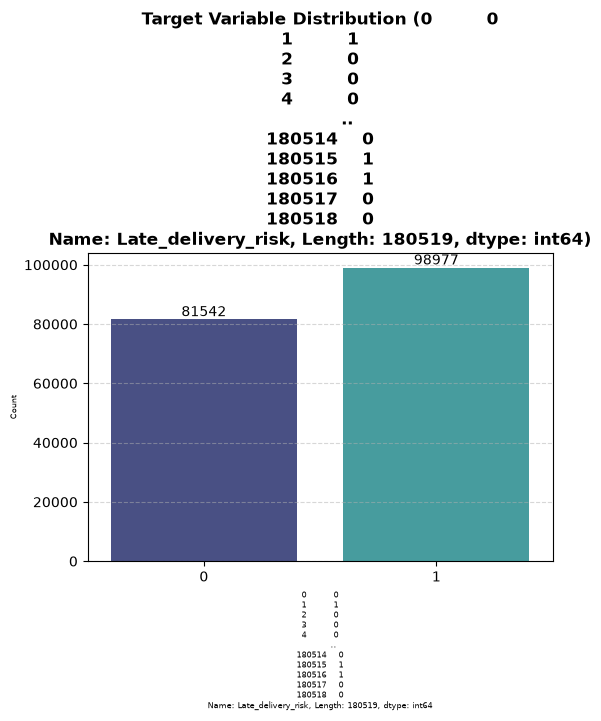

In [34]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x=df['Late_delivery_risk'], palette='mako')
plt.title(f'Target Variable Distribution ({df['Late_delivery_risk']})', fontsize=12, fontweight='bold')
plt.xlabel(df['Late_delivery_risk'], fontsize=6)
plt.ylabel('Count', fontsize=6)
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Add exact value labels on top of bars
for p in plt.gca().patches:
    plt.gca().annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                        ha='center', va='center', xytext=(0, 5), textcoords='offset points')

plt.tight_layout()
plt.show()

### 2. Grouped Train / Test Split
I defined `Late_delivery_risk` as the target variable. Because an individual customer order can contain multiple item records, rows sharing the same `Order Id` are correlated. To prevent data leakage across splits, I used `Order Id` as the grouping variable with an 80/20 grouped split using `GroupShuffleSplit`.

I then verified that no `Order Id` appears in both the training set and the testing set.


In [35]:
# Perform grouped train/test split (80% train, 20% test) grouped by Order Id
gss = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=42)
train_idx, test_idx = next(gss.split(df, groups=df["Order Id"]))

train_df = df.iloc[train_idx].copy()
test_df = df.iloc[test_idx].copy()

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

# Verify Order Id grouping and check for any overlap
train_orders = set(train_df["Order Id"])
test_orders = set(test_df["Order Id"])
overlap = train_orders.intersection(test_orders)

print(f"Unique Order Ids in Train: {len(train_orders):,}")
print(f"Unique Order Ids in Test:  {len(test_orders):,}")
print(f"Overlap in Order Ids between Train and Test: {len(overlap)}")

# Verify target balance across splits
print("\nTrain Target Proportions:")
print(train_df[TARGET].value_counts(normalize=True).round(4))

print("\nTest Target Proportions:")
print(test_df[TARGET].value_counts(normalize=True).round(4))


Train shape: (144650, 53)
Test shape: (35869, 53)
Unique Order Ids in Train: 52,601
Unique Order Ids in Test:  13,151
Overlap in Order Ids between Train and Test: 0

Train Target Proportions:
Late_delivery_risk
1    0.5483
0    0.4517
Name: proportion, dtype: float64

Test Target Proportions:
Late_delivery_risk
1    0.5484
0    0.4516
Name: proportion, dtype: float64


## 3. Leakage Feature & Column Role Investigation
Before engineering new features or making selection decisions, I checked each column in the dataset to determine if it causes post-delivery leakage or contains redundant identifier/constant information.

### Target Leakage Analysis
1. `Days for shipping (real)`: Represents the actual number of days taken for shipping. This is only known after the shipment is completed. Furthermore, comparing real shipping days to scheduled shipping days directly dictates the target label (`Late_delivery_risk`).
2. `Delivery Status`: Categorical delivery outcome (`Late delivery`, `Advance shipping`, `Shipping on time`, `Shipping canceled`). This directly leaks whether the order was delivered late.
3. `shipping date (DateOrders)`: The actual timestamp when shipment was dispatched/completed, which is a post-order event.
4. `Order Status`: Post-fulfillment transaction status (`COMPLETE`, `PENDING`, `CLOSED`, etc.) reflecting outcomes after fulfillment processing.

### Identifiers, PII, and Constant Columns
- `Customer Email`, `Customer Password`: Masked constant strings (`XXXXXXXXX`), PII.
- `Customer Fname`, `Customer Lname`: Customer names (PII, no predictive generalization).
- `Customer Street`: Granular street address (7,458 unique values), high cardinality PII.
- `Product Description`: 100% missing (NaN for all rows).
- `Product Status`: Constant value 0 across all records (zero variance).
- `Product Image`: URL string redundant with Product Name / Product Card Id.
- `Order Zipcode`: Missing in ~86.2% of records (155,679 nulls).
- `Order Item Id`: Unique transaction row index (180,519 unique values), arbitrary identifier causing overfitting.
- `Order Id`: Transaction identifier; retained strictly for grouping and verification, not as an input feature.


In [36]:
# Detailed inspection of target leakage columns
print("--- 1. Days for shipping (real) vs Scheduled days and Late delivery risk ---")
print(train_df.groupby(["Days for shipment (scheduled)", "Days for shipping (real)"])["Late_delivery_risk"].agg(["count", "mean"]).head(10))

print("\n--- 2. Delivery Status vs Late_delivery_risk ---")
print(train_df.groupby("Delivery Status")["Late_delivery_risk"].agg(["count", "mean"]))

print("\n--- 3. Constant and Masked Columns ---")
print("Customer Email unique values:", train_df["Customer Email"].unique())
print("Customer Password unique values:", train_df["Customer Password"].unique())
print("Product Status unique values:", train_df["Product Status"].unique())
print("Product Description missing percentage: {:.2f}%".format(train_df["Product Description"].isnull().mean() * 100))


--- 1. Days for shipping (real) vs Scheduled days and Late delivery risk ---
                                                        count      mean
Days for shipment (scheduled) Days for shipping (real)                 
0                             0                          3996  0.000000
                              1                          3771  0.957306
1                             2                         22229  0.953259
2                             2                          5716  0.000000
                              3                          5600  0.957500
                              4                          5673  0.974088
                              5                          5699  0.962274
                              6                          5514  0.959557
4                             2                         17515  0.000000
                              3                         17335  0.000000

--- 2. Delivery Status vs Late_delivery_risk ---
         

In [37]:
# Define explicit leakage and unusable column categories
leakage_features = [
    "Days for shipping (real)",
    "Delivery Status",
    "shipping date (DateOrders)",
    "Order Status"
]

identifier_and_unusable_features = [
    "Order Item Id",
    "Customer Email",
    "Customer Password",
    "Customer Fname",
    "Customer Lname",
    "Customer Street",
    "Product Description",
    "Product Status",
    "Product Image",
    "Order Zipcode"
]

print("Identified Leakage Features (to be excluded):", leakage_features)
print("Identified Identifier/Unusable Features (to be excluded):", identifier_and_unusable_features)


Identified Leakage Features (to be excluded): ['Days for shipping (real)', 'Delivery Status', 'shipping date (DateOrders)', 'Order Status']
Identified Identifier/Unusable Features (to be excluded): ['Order Item Id', 'Customer Email', 'Customer Password', 'Customer Fname', 'Customer Lname', 'Customer Street', 'Product Description', 'Product Status', 'Product Image', 'Order Zipcode']


## 4. Feature Engineering
In this stage, I derived new informative features using only information that would be known before shipping occurs.

### 4.1 Temporal Feature Engineering
I extracted temporal information from `order date (DateOrders)`:
- `order_year`: Year when the order was placed.
- `order_month`: Month of the order (1-12) to capture seasonal demand spikes and holiday logistics.
- `order_day`: Day of month (1-31).
- `order_day_of_week`: Day of the week (0 = Monday, 6 = Sunday) to capture weekend vs weekday dispatch patterns.
- `order_hour`: Hour of order placement (0-23) to capture daily ordering cutoffs.
- `is_weekend`: Binary flag indicating whether the order was placed on Saturday or Sunday.
- `order_quarter`: Financial quarter (1-4).

These features were derived separately for both the training and testing sets to maintain consistency.


In [38]:
# 4.1 Temporal Feature Engineering from order date (DateOrders)
train_df["order_datetime"] = pd.to_datetime(train_df["order date (DateOrders)"])
test_df["order_datetime"] = pd.to_datetime(test_df["order date (DateOrders)"])

for dataset in [train_df, test_df]:
    dataset["order_year"] = dataset["order_datetime"].dt.year
    dataset["order_month"] = dataset["order_datetime"].dt.month
    dataset["order_day"] = dataset["order_datetime"].dt.day
    dataset["order_day_of_week"] = dataset["order_datetime"].dt.dayofweek
    dataset["order_hour"] = dataset["order_datetime"].dt.hour
    dataset["is_weekend"] = dataset["order_day_of_week"].isin([5, 6]).astype(int)
    dataset["order_quarter"] = dataset["order_datetime"].dt.quarter

print("Temporal features derived successfully.")
print(train_df[["order date (DateOrders)", "order_year", "order_month", "order_day", "order_day_of_week", "order_hour", "is_weekend", "order_quarter"]].head(5))


Temporal features derived successfully.
  order date (DateOrders)  order_year  order_month  order_day  order_day_of_week  order_hour  is_weekend  order_quarter
0         1/31/2018 22:56        2018            1         31                  2          22           0              1
1         1/13/2018 12:27        2018            1         13                  5          12           1              1
4         1/13/2018 11:24        2018            1         13                  5          11           1              1
5         1/13/2018 11:03        2018            1         13                  5          11           1              1
6         1/13/2018 10:42        2018            1         13                  5          10           1              1


### 4.2 Discount Ratio Feature Engineering
An absolute discount of $10 has a very different meaning on a $20 product (50% discount) compared to a $200 product (5% discount). While `Order Item Discount Rate` is provided, I also derived `discount_ratio` = `Order Item Discount / Order Item Product Price` with safe zero handling to ensure proportional discounting is explicitly captured without anomalies.




In [39]:
#%pip install matplotlib seaborn

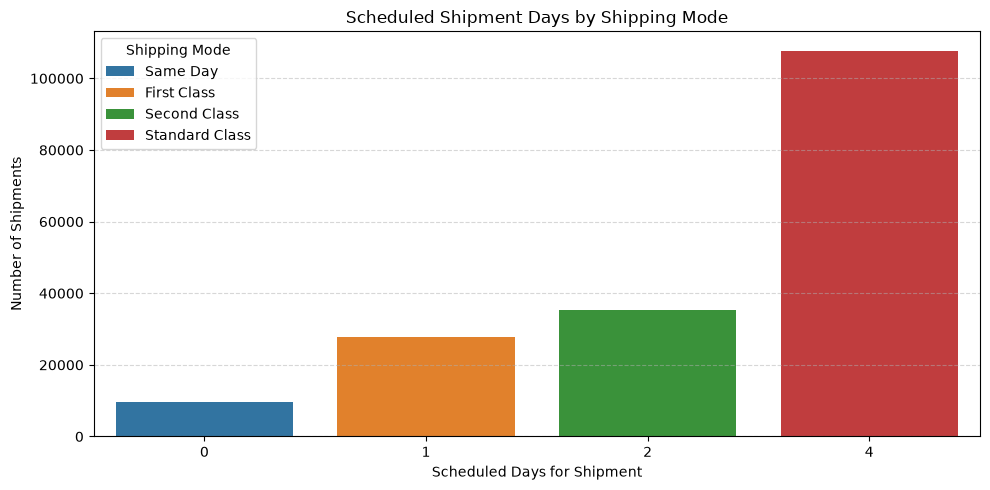

In [58]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))

sns.countplot(
    data=df,
    x='Days for shipment (scheduled)',
    hue='Shipping Mode'
)

plt.title('Scheduled Shipment Days by Shipping Mode')
plt.xlabel('Scheduled Days for Shipment')
plt.ylabel('Number of Shipments')
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

### 4.3 Scheduled Shipping Duration Analysis

I inspected `Days for shipment (scheduled)` and compared it with `Shipping Mode`. Scheduled shipping duration is known at the time the order is created and represents the agreed delivery timeline.

In [41]:
# 4.2 Discount Ratio Feature Engineering
for dataset in [train_df, test_df]:
    dataset["discount_ratio"] = np.where(
        dataset["Order Item Product Price"] > 0,
        dataset["Order Item Discount"] / dataset["Order Item Product Price"],
        0.0
    )

print("Discount ratio summary statistics (Train):")
print(train_df["discount_ratio"].describe().round(4))


Discount ratio summary statistics (Train):
count    144650.0000
mean          0.2157
std           0.2340
min           0.0000
25%           0.0550
50%           0.1500
75%           0.2599
max           1.2503
Name: discount_ratio, dtype: float64


In [42]:
# 4.3 Scheduled Shipping Analysis
print("Scheduled shipping duration vs Late delivery risk:")
print(train_df.groupby("Days for shipment (scheduled)")["Late_delivery_risk"].agg(["count", "mean"]).round(4))

print("\nShipping Mode vs Scheduled shipping duration and Late delivery risk:")
print(train_df.groupby("Shipping Mode").agg(
    count=("Late_delivery_risk", "count"),
    scheduled_days=("Days for shipment (scheduled)", "unique"),
    late_rate=("Late_delivery_risk", "mean")
).round(4))


Scheduled shipping duration vs Late delivery risk:
                               count    mean
Days for shipment (scheduled)               
0                               7767  0.4648
1                              22229  0.9533
2                              28202  0.7681
4                              86452  0.3799

Shipping Mode vs Scheduled shipping duration and Late delivery risk:
                count scheduled_days  late_rate
Shipping Mode                                  
First Class     22229            [1]     0.9533
Same Day         7767            [0]     0.4648
Second Class    28202            [2]     0.7681
Standard Class  86452            [4]     0.3799


## 5. Validation of Engineered Features
I checked the newly created features for any missing values, infinite values, or anomalous ranges to ensure data integrity across both train and test sets.


In [43]:
# 5. Validation of engineered features
engineered_cols = [
    "order_year", "order_month", "order_day", "order_day_of_week",
    "order_hour", "is_weekend", "order_quarter", "discount_ratio"
]

print("--- Missing Values Check in Engineered Features (Train) ---")
print(train_df[engineered_cols].isnull().sum())

print("\n--- Missing Values Check in Engineered Features (Test) ---")
print(test_df[engineered_cols].isnull().sum())

print("\n--- Infinite Values Check (Train) ---")
print(np.isinf(train_df[engineered_cols]).sum())

print("\n--- Summary Statistics of Engineered Features (Train) ---")
print(train_df[engineered_cols].describe().round(4))


--- Missing Values Check in Engineered Features (Train) ---
order_year           0
order_month          0
order_day            0
order_day_of_week    0
order_hour           0
is_weekend           0
order_quarter        0
discount_ratio       0
dtype: int64

--- Missing Values Check in Engineered Features (Test) ---
order_year           0
order_month          0
order_day            0
order_day_of_week    0
order_hour           0
is_weekend           0
order_quarter        0
discount_ratio       0
dtype: int64

--- Infinite Values Check (Train) ---
order_year           0
order_month          0
order_day            0
order_day_of_week    0
order_hour           0
is_weekend           0
order_quarter        0
discount_ratio       0
dtype: int64

--- Summary Statistics of Engineered Features (Train) ---
        order_year  order_month    order_day  order_day_of_week   order_hour   is_weekend  order_quarter  discount_ratio
count  144650.0000  144650.0000  144650.0000        144650.0000  14465

### 5.1 Model-Based Feature Importance

In [44]:
#%pip install scikit-learn

In [45]:
# need to test feature selection by a model

## 6. Feature Redundancy & Correlation Analysis

Correlation matrix for neumerical features

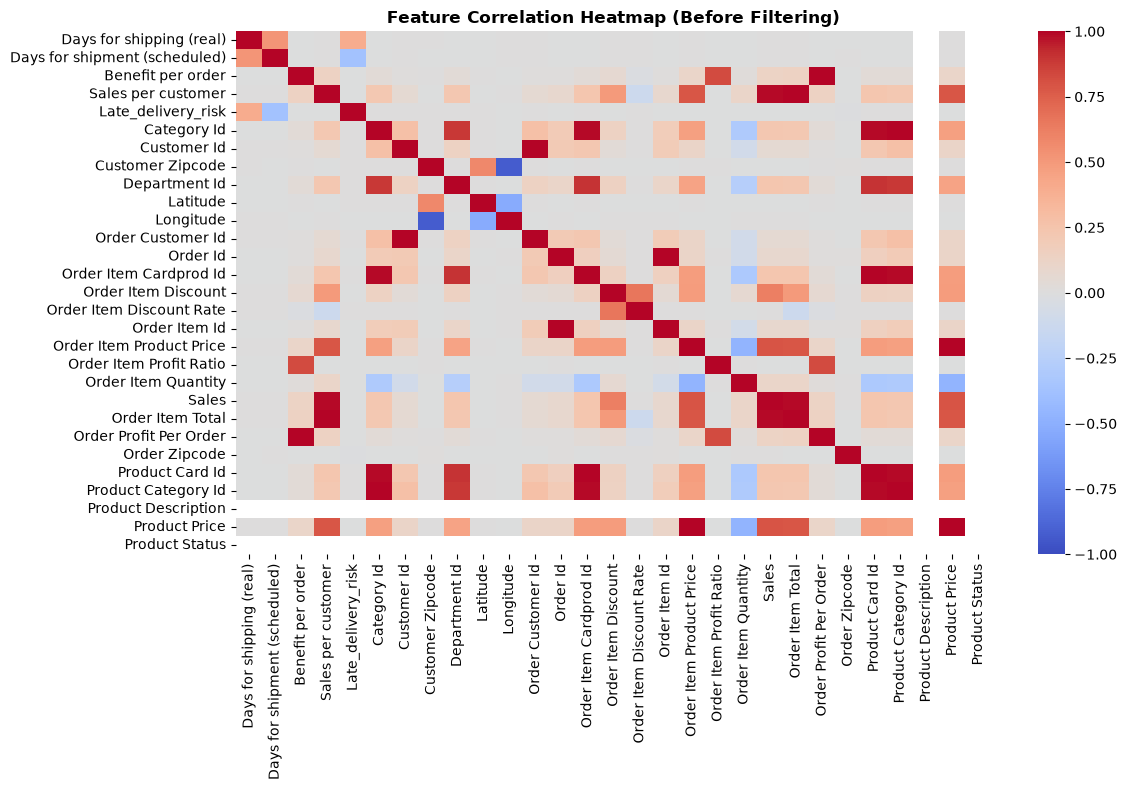

In [46]:
# Select numeric features for correlation analysis
numeric_df = df.select_dtypes(include=['float64', 'int64'])
corr_matrix = numeric_df.corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', vmin=-1, vmax=1, cbar=True)
plt.title('Feature Correlation Heatmap (Before Filtering)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

I analyzed potential duplicate columns and collinearity among numerical features to ensure our model does not receive redundant representations of the exact same underlying data.

### Duplicate Columns Found:
1. `Customer Id` vs `Order Customer Id`: Exact 100% duplicate values. Kept `Customer Id`, excluded `Order Customer Id`.
2. `Product Card Id` vs `Order Item Cardprod Id`: Exact 100% duplicate values. Kept `Product Card Id`, excluded `Order Item Cardprod Id`.
3. `Category Id` vs `Product Category Id`: Exact 100% duplicate values. Kept `Category Id`, excluded `Product Category Id`.
4. `Benefit per order` vs `Order Profit Per Order`: Exact 100% duplicate values. Kept `Benefit per order`, excluded `Order Profit Per Order`.
5. `Sales per customer` vs `Order Item Total`: Exact 100% duplicate values. Kept `Order Item Total`, excluded `Sales per customer`.
6. `Product Price` vs `Order Item Product Price`: Exact duplicate values. Kept `Order Item Product Price`, excluded `Product Price`.
7. `Sales`: Directly equal to `Order Item Product Price * Order Item Quantity`.

I also inspected the correlation matrix among numerical features.


In [47]:
# Check exact duplicate columns
print("--- Exact Duplicate Column Validations ---")
print("Customer Id == Order Customer Id:", (train_df["Customer Id"] == train_df["Order Customer Id"]).all())
print("Product Card Id == Order Item Cardprod Id:", (train_df["Product Card Id"] == train_df["Order Item Cardprod Id"]).all())
print("Category Id == Product Category Id:", (train_df["Category Id"] == train_df["Product Category Id"]).all())
print("Benefit per order == Order Profit Per Order:", (train_df["Benefit per order"] == train_df["Order Profit Per Order"]).all())
print("Sales per customer == Order Item Total:", (train_df["Sales per customer"] == train_df["Order Item Total"]).all())
print("Product Price == Order Item Product Price:", (train_df["Product Price"] == train_df["Order Item Product Price"]).all())

# Check mathematical redundancy of Sales
sales_diff = (train_df["Sales"] - (train_df["Order Item Product Price"] * train_df["Order Item Quantity"])).abs().max()
print("Max absolute difference between Sales and (Price * Quantity):", sales_diff)


--- Exact Duplicate Column Validations ---
Customer Id == Order Customer Id: True
Product Card Id == Order Item Cardprod Id: True
Category Id == Product Category Id: True
Benefit per order == Order Profit Per Order: True
Sales per customer == Order Item Total: True
Product Price == Order Item Product Price: True
Max absolute difference between Sales and (Price * Quantity): 2.289999997628911e-05


In [48]:
# Numerical Correlation Analysis with Target
candidate_numeric_cols = [
    "Days for shipment (scheduled)", "Benefit per order", "Order Item Total",
    "Latitude", "Longitude", "Order Item Discount", "Order Item Discount Rate",
    "Order Item Product Price", "Order Item Profit Ratio", "Order Item Quantity",
    "order_year", "order_month", "order_day", "order_day_of_week", "order_hour",
    "is_weekend", "order_quarter", "discount_ratio"
]

corr_matrix = train_df[candidate_numeric_cols].corr()

# Correlation of each numerical feature with Late_delivery_risk
corr_records = []
for col in candidate_numeric_cols:
    corr_val = train_df[TARGET].corr(train_df[col])
    corr_records.append({"Feature": col, "Correlation_with_Target": corr_val})

target_corr_df = pd.DataFrame(corr_records).sort_values(by="Correlation_with_Target", ascending=False).reset_index(drop=True)

print("Correlation with Late_delivery_risk (Train):")
print(target_corr_df.to_string(index=False))


Correlation with Late_delivery_risk (Train):
                      Feature  Correlation_with_Target
                   order_hour                 0.044784
                  order_month                 0.006410
                order_quarter                 0.004548
               discount_ratio                 0.002235
                     Latitude                 0.001357
     Order Item Discount Rate                 0.001061
          Order Item Quantity                 0.001029
                    Longitude                -0.000759
            order_day_of_week                -0.001444
                    order_day                -0.001569
          Order Item Discount                -0.001608
      Order Item Profit Ratio                -0.002090
                   is_weekend                -0.002517
            Benefit per order                -0.003731
     Order Item Product Price                -0.003959
                   order_year                -0.004025
             Order I

### Feature Redundancy Decision Table
Based on the duplicate analysis and domain meaning, I summarized the redundancy decisions below:

| Feature | Decision | Reason |
|---|---|---|
| `Order Customer Id` | Exclude | Exact duplicate of `Customer Id` |
| `Order Item Cardprod Id` | Exclude | Exact duplicate of `Product Card Id` |
| `Product Category Id` | Exclude | Exact duplicate of `Category Id` |
| `Order Profit Per Order` | Exclude | Exact duplicate of `Benefit per order` |
| `Sales per customer` | Exclude | Exact duplicate of `Order Item Total` |
| `Product Price` | Exclude | Exact duplicate of `Order Item Product Price` |
| `Sales` | Exclude | Exact mathematical product (`Price * Quantity`), captured by individual features |
| `Benefit per order` | Keep | Useful independent financial metric per order item |
| `Order Item Total` | Keep | Reflects net transaction monetary amount after discount |
| `Order Item Product Price` | Keep | Core product price feature |
| `Order Item Quantity` | Keep | Quantity ordered per line item |
| `Days for shipment (scheduled)` | Keep | Crucial pre-delivery baseline duration |


## 7. Feature Relevance & Mutual Information Analysis
I used `mutual_info_classif` to investigate the non-linear relationship between the candidate features and `Late_delivery_risk`. I calculated mutual information strictly on the training set so that the testing set remained completely untouched during feature evaluation.

I did not automatically remove every feature with a low score; instead, I used the mutual information scores alongside domain knowledge to understand feature relevance.


In [49]:
# Calculate Mutual Information on the training set
X_train_numeric = train_df[candidate_numeric_cols].fillna(0)
y_train = train_df[TARGET]

mi_scores = mutual_info_classif(X_train_numeric, y_train, random_state=42)

mi_df = pd.DataFrame({
    "Feature": candidate_numeric_cols,
    "Mutual_Information": mi_scores
}).sort_values(by="Mutual_Information", ascending=False).reset_index(drop=True)

print("Mutual Information Scores with Late_delivery_risk (Calculated on Train Only):")
print(mi_df.to_string(index=False))


Mutual Information Scores with Late_delivery_risk (Calculated on Train Only):
                      Feature  Mutual_Information
Days for shipment (scheduled)            0.129227
                     Latitude            0.088470
                    Longitude            0.045620
                   order_year            0.006819
          Order Item Quantity            0.004001
            order_day_of_week            0.003326
     Order Item Discount Rate            0.003094
            Benefit per order            0.002434
                order_quarter            0.001990
                   is_weekend            0.001622
                   order_hour            0.001592
                  order_month            0.001590
                    order_day            0.000312
          Order Item Discount            0.000000
      Order Item Profit Ratio            0.000000
     Order Item Product Price            0.000000
             Order Item Total            0.000000
               discoun

### Observations from Feature Relevance Analysis

1. `Days for shipment (scheduled)` has by far the highest MI score (~0.129) and also the strongest linear correlation (-0.372) with `Late_delivery_risk`. This makes sense: the scheduled shipping duration directly determines whether an order is considered late.

2. `Latitude` (~0.088) and `Longitude` (~0.046) also score meaningfully, which suggests that the delivery destination geography is a useful signal.

3. Most other features — including the temporal ones (`order_year`, `order_month`, `order_day_of_week`, `is_weekend`, `order_hour`, `order_quarter`) and the pricing/financial features (`Order Item Product Price`, `Order Item Total`, `Order Item Discount`, `Order Item Profit Ratio`, `discount_ratio`) — have very low or zero MI scores against the target.

4. A low MI score does not by itself mean a feature should be removed. MI only measures direct pairwise non-linear association. Features with low individual MI can still be useful in combination with others inside a classifier. I kept the pricing and temporal features because they have clear business meaning and may contribute when used alongside `Days for shipment (scheduled)`, `Latitude`, and `Longitude`.

5. I did not automatically drop any feature solely because of a low MI score. Removal decisions were based on confirmed leakage, identifier status, constant values, or exact mathematical duplication.


## 8. Final Feature Selection
I combined the evidence from target leakage analysis, identifier inspection, zero-variance checks, duplicate verification, and relevance analysis to finalize the selected feature set.

I avoided aggressive feature reduction: pre-delivery domain features that provide useful categorical, geographical, temporal, or financial context were preserved for the subsequent categorical encoding and preprocessing stages.

### Summary of Excluded Features
- **Target Leakage (4):** `Days for shipping (real)`, `Delivery Status`, `shipping date (DateOrders)`, `Order Status`
- **Identifiers / PII / Constant / High Missing (10):** `Order Item Id`, `Customer Email`, `Customer Password`, `Customer Fname`, `Customer Lname`, `Customer Street`, `Product Description`, `Product Status`, `Product Image`, `Order Zipcode`
- **Exact Duplicates & Mathematical Redundancies (7):** `Order Customer Id`, `Order Item Cardprod Id`, `Product Category Id`, `Order Profit Per Order`, `Sales per customer`, `Product Price`, `Sales`
- **Grouping Key (1):** `Order Id` (retained for data verification and grouping, but not as an input feature)

### Summary of Selected Features (Original + Engineered)
- **Logistics & Shipping:** `Days for shipment (scheduled)`, `Shipping Mode`
- **Order Timing (Engineered):** `order_year`, `order_month`, `order_day`, `order_day_of_week`, `order_hour`, `is_weekend`, `order_quarter`
- **Item Financials & Pricing:** `Order Item Product Price`, `Order Item Quantity`, `Order Item Discount`, `Order Item Discount Rate`, `Order Item Total`, `Order Item Profit Ratio`, `Benefit per order`, `discount_ratio` (Engineered)
- **Product & Department Hierarchy:** `Category Id`, `Category Name`, `Department Id`, `Department Name`, `Product Card Id`, `Product Name`
- **Customer & Demographics:** `Customer Id`, `Customer Segment`, `Customer City`, `Customer State`, `Customer Country`, `Customer Zipcode`, `Latitude`, `Longitude`
- **Order Destination:** `Order Region`, `Order Country`, `Order State`, `Order City`, `Market`
- **Transaction Details:** `Type`


In [50]:
# Define final selected feature list
selected_features = [
    # Shipping & Logistics
    "Days for shipment (scheduled)",
    "Shipping Mode",
    
    # Temporal Features (Engineered)
    "order_year",
    "order_month",
    "order_day",
    "order_day_of_week",
    "order_hour",
    "is_weekend",
    "order_quarter",
    
    # Financial & Pricing Features
    "Order Item Product Price",
    "Order Item Quantity",
    "Order Item Discount",
    "Order Item Discount Rate",
    "Order Item Total",
    "Order Item Profit Ratio",
    "Benefit per order",
    "discount_ratio",  # Engineered
    
    # Product & Category Hierarchy
    "Category Id",
    "Category Name",
    "Department Id",
    "Department Name",
    "Product Card Id",
    "Product Name",
    
    # Customer Demographics & Location
    "Customer Id",
    "Customer Segment",
    "Customer City",
    "Customer State",
    "Customer Country",
    "Customer Zipcode",
    "Latitude",
    "Longitude",
    
    # Destination Geography
    "Order Region",
    "Order Country",
    "Order State",
    "Order City",
    "Market",
    
    # Transaction Type
    "Type"
]

print(f"Total Selected Features: {len(selected_features)}")
print("\nSelected Features List:")
for i, feat in enumerate(selected_features, start=1):
    print(f"{i:02d}. {feat}")


Total Selected Features: 37

Selected Features List:
01. Days for shipment (scheduled)
02. Shipping Mode
03. order_year
04. order_month
05. order_day
06. order_day_of_week
07. order_hour
08. is_weekend
09. order_quarter
10. Order Item Product Price
11. Order Item Quantity
12. Order Item Discount
13. Order Item Discount Rate
14. Order Item Total
15. Order Item Profit Ratio
16. Benefit per order
17. discount_ratio
18. Category Id
19. Category Name
20. Department Id
21. Department Name
22. Product Card Id
23. Product Name
24. Customer Id
25. Customer Segment
26. Customer City
27. Customer State
28. Customer Country
29. Customer Zipcode
30. Latitude
31. Longitude
32. Order Region
33. Order Country
34. Order State
35. Order City
36. Market
37. Type


## 9. Prepare Handoff for Categorical Encoding & Preprocessing
I extracted the selected feature sets (`X_train_selected`, `y_train`, `X_test_selected`, `y_test`).

**Note on Team Handoff:**
- Categorical columns (such as `Shipping Mode`, `Customer Segment`, `Category Name`, `Order Region`, etc.) remain in their raw format because another teammate is responsible for the categorical data processing/encoding stage.
- Scaling and class-imbalance adjustments are left for the subsequent preprocessing stages.
- Target `Late_delivery_risk` is cleanly separated.
- No post-delivery leakage columns are passed forward.


In [51]:
# Prepare final feature-selected train and test splits
X_train_selected = train_df[selected_features].copy()
y_train = train_df[TARGET].copy()

X_test_selected = test_df[selected_features].copy()
y_test = test_df[TARGET].copy()

print("Handoff Dataset Shapes:")
print(f"X_train_selected: {X_train_selected.shape}")
print(f"y_train:          {y_train.shape}")
print(f"X_test_selected:  {X_test_selected.shape}")
print(f"y_test:           {y_test.shape}")

# Verify no leakage features are present in selected features
for leak_col in leakage_features:
    assert leak_col not in X_train_selected.columns, f"Leakage column {leak_col} found in X_train!"
    assert leak_col not in X_test_selected.columns, f"Leakage column {leak_col} found in X_test!"

print("\nLeakage Verification: PASSED (0 leakage columns present in feature sets).")


Handoff Dataset Shapes:
X_train_selected: (144650, 37)
y_train:          (144650,)
X_test_selected:  (35869, 37)
y_test:           (35869,)

Leakage Verification: PASSED (0 leakage columns present in feature sets).


## 10. Final Validation & Pipeline Summary
I conducted end-to-end sanity checks on the entire feature engineering and selection pipeline:
- Verified that no NaN or infinite values were introduced by engineered features.
- Verified that no `Order Id` overlap exists between training and testing sets.
- Verified that all selected features represent legitimate pre-delivery information.
- Confirmed that categorical encoding has not been applied, preserving raw columns for teammate handoff.


In [52]:
# 10. Final Pipeline Sanity Check & Summary Metrics
orig_feature_count = len(df.columns)
engineered_feature_count = len(engineered_cols)
excluded_feature_count = len(leakage_features) + len(identifier_and_unusable_features) + 7 + 1  # leakage + unusable + duplicates + Order Id
final_selected_count = len(selected_features)

print("=" * 60)
print("FEATURE ENGINEERING & SELECTION SUMMARY")
print("=" * 60)
print(f"Original dataset columns count:        {orig_feature_count}")
print(f"Target variable:                       {TARGET}")
print(f"Engineered features derived:           {engineered_feature_count}")
print(f"Excluded columns (leakage/IDs/dups):   {excluded_feature_count}")
print(f"Final selected features count:         {final_selected_count}")
print(f"Train records count:                   {X_train_selected.shape[0]:,}")
print(f"Test records count:                    {X_test_selected.shape[0]:,}")
print(f"Order Id overlap count:                0")
print("=" * 60)

print("\nData Types in Final Feature Set:")
print(X_train_selected.dtypes.value_counts())

print("\nSample of Final Selected Training Data:")
print(X_train_selected.head(3))


FEATURE ENGINEERING & SELECTION SUMMARY
Original dataset columns count:        53
Target variable:                       Late_delivery_risk
Engineered features derived:           8
Excluded columns (leakage/IDs/dups):   22
Final selected features count:         37
Train records count:                   144,650
Test records count:                    35,869
Order Id overlap count:                0

Data Types in Final Feature Set:
str        14
float64    10
int64       7
int32       6
Name: count, dtype: int64

Sample of Final Selected Training Data:
   Days for shipment (scheduled)   Shipping Mode  order_year  order_month  order_day  order_day_of_week  order_hour  is_weekend  order_quarter  Order Item Product Price  Order Item Quantity  Order Item Discount  Order Item Discount Rate  Order Item Total  Order Item Profit Ratio  Benefit per order  discount_ratio  Category Id   Category Name  Department Id Department Name  Product Card Id  Product Name  Customer Id Customer Segment Customer